# DL068 可执行实验

代码单元按序真实运行，输出保存在notebook_outputs。

In [1]:
from pathlib import Path
import sys,json,numpy as np,torch
import experiment as e
import matplotlib.pyplot as plt
from io import BytesIO
from IPython.display import Image,display
def show(fig):
    b=BytesIO();fig.savefig(b,format='png',dpi=140,bbox_inches='tight');display(Image(data=b.getvalue()));plt.close(fig)
torch.set_num_threads(1)
print({'python':sys.version.split()[0],'torch':torch.__version__,'device':'CPU'})

{'python': '3.12.14', 'torch': '2.14.1+cpu', 'device': 'CPU'}


## 先手算分位数

In [2]:
print(np.quantile([1,2,3,4,100],[.5,.95],method="linear"))

[ 3.  80.8]


## 运行合同与语义测试

In [3]:
import unittest,test_experiment
z=unittest.TextTestRunner().run(unittest.defaultTestLoader.loadTestsFromModule(test_experiment))
if not z.wasSuccessful():raise RuntimeError('tests failed')

.

.

.

.

.

.

----------------------------------------------------------------------
Ran 6 tests in 1.543s

OK


## 真实训练导出重载与计时

In [4]:
r=e.run("notebook_outputs")
print({k:r[k] for k in ["accuracy","wrong_preprocessing_accuracy","export_checks","requests"]})

{'accuracy': 0.9895833333333334, 'wrong_preprocessing_accuracy': 0.3723958333333333, 'export_checks': {'1': {'max_abs_logit_error': 3.814697265625e-06, 'argmax_mismatches': 0}, '32': {'max_abs_logit_error': 0.0, 'argmax_mismatches': 0}}, 'requests': [{'status': 'ok', 'prediction': 1}, {'status': 'rejected', 'reason': 'expected finite float32 [1,4]', 'prediction': None}, {'status': 'rejected', 'reason': 'expected finite float32 [1,4]', 'prediction': None}, {'status': 'rejected', 'reason': 'expected finite float32 [1,4]', 'prediction': None}]}


## 观察全部原始计时

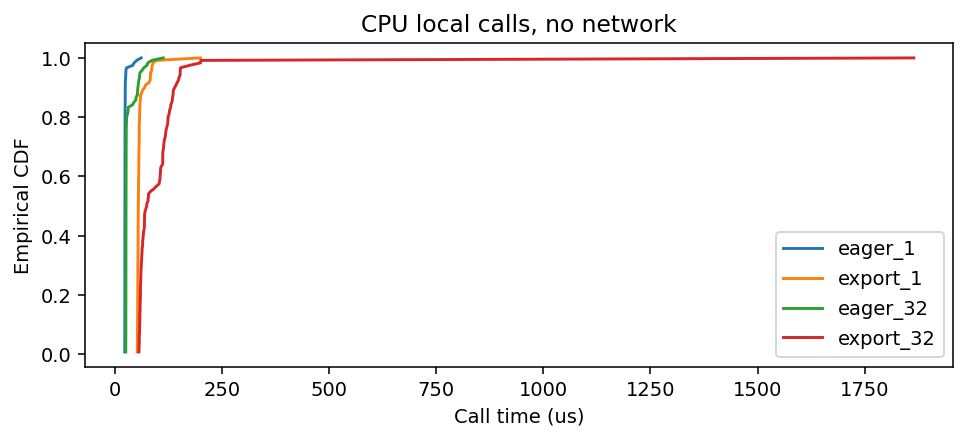

In [5]:
fig,ax=plt.subplots(figsize=(8,3))
for key in r["timings"]:
    v=np.sort(r["timings"][key]["samples_us"]);ax.plot(v,np.arange(1,len(v)+1)/len(v),label=key)
ax.set(xlabel="Call time (us)",ylabel="Empirical CDF",title="CPU local calls, no network");ax.legend();show(fig)

## 检查保存的权重和导出图

In [6]:
a=np.load("notebook_outputs/data.npz");state=torch.load("notebook_outputs/model.pt",weights_only=True)
m=e.Model(state["mean"],state["scale"]);m.load_state_dict(state);m.eval()
exported=torch.export.load("notebook_outputs/model_batch32.pt2").module()
x=torch.from_numpy(a["x"][768:])
with torch.inference_mode():
    z=m(x);g=torch.cat([exported(x[i:i+32]) for i in range(0,len(x),32)])
torch.testing.assert_close(z,g,rtol=1e-5,atol=1e-5)
print("all 384 exported predictions checked",float((z-g).abs().max()))

all 384 exported predictions checked 0.0


## 区分吞吐与延迟

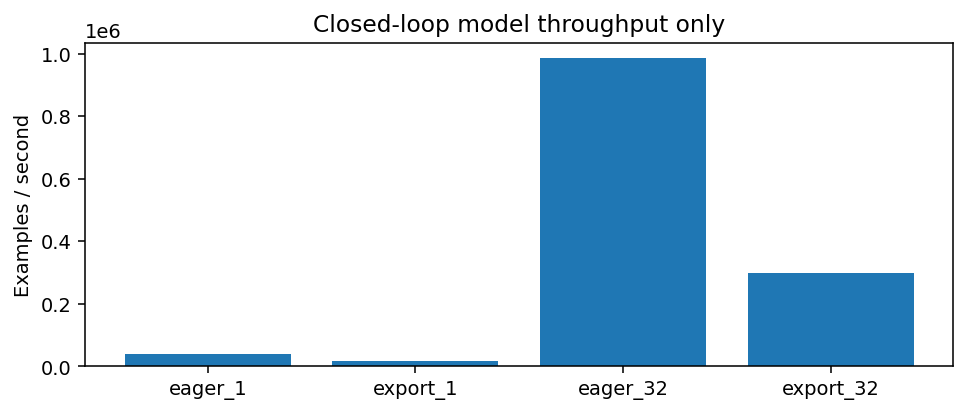

['CPU single-process sequential microbenchmark; no network, server, concurrency or GPU', 'warm-process reload and new-interpreter startup measured separately; OS cache not reset; no container cold-start test', 'torch.export graph execution is not AOT compilation or universal deployment portability']


In [7]:
fig,ax=plt.subplots(figsize=(8,3));keys=list(r["timings"])
ax.bar(keys,[r["timings"][k]["throughput_examples_per_second"] for k in keys]);ax.set(ylabel="Examples / second",title="Closed-loop model throughput only");show(fig)
print(r["limits"])